데이터 불러오는 중...

데이터 크기 (행, 열): (2332531, 12)

[데이터 처음 5줄 미리보기]


,RowId,Date,SecuritiesCode,Open,High,Low,Close,Volume,AdjustmentFactor,ExpectedDividend,SupervisionFlag,Target
0,20170104_1301,2017-01-04,1301,2734.0,2755.0,2730.0,2742.0,31400,1.0,NaN,False,0.000730
1,20170104_1332,2017-01-04,1332,568.0,576.0,563.0,571.0,2798500,1.0,NaN,False,0.012324
2,20170104_1333,2017-01-04,1333,3150.0,3210.0,3140.0,3210.0,270800,1.0,NaN,False,0.006154
3,20170104_1376,2017-01-04,1376,1510.0,1550.0,1510.0,1550.0,11300,1.0,NaN,False,0.011053
4,20170104_1377,2017-01-04,1377,3270.0,3350.0,3270.0,3330.0,150800,1.0,NaN,False,0.003026


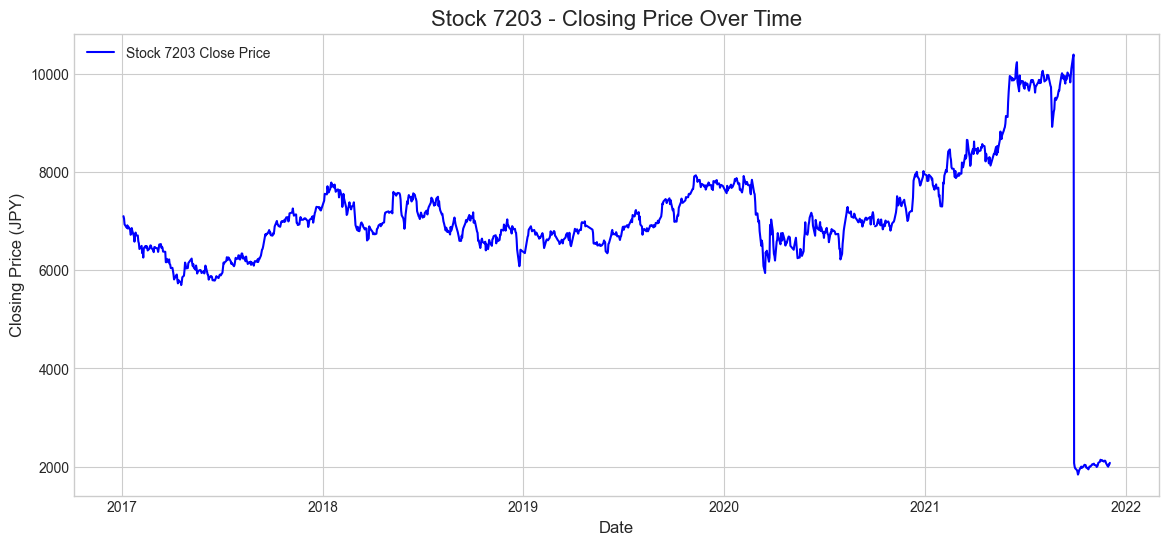


전체 데이터 중 Target 결측치 수: 238개 (0.01%)


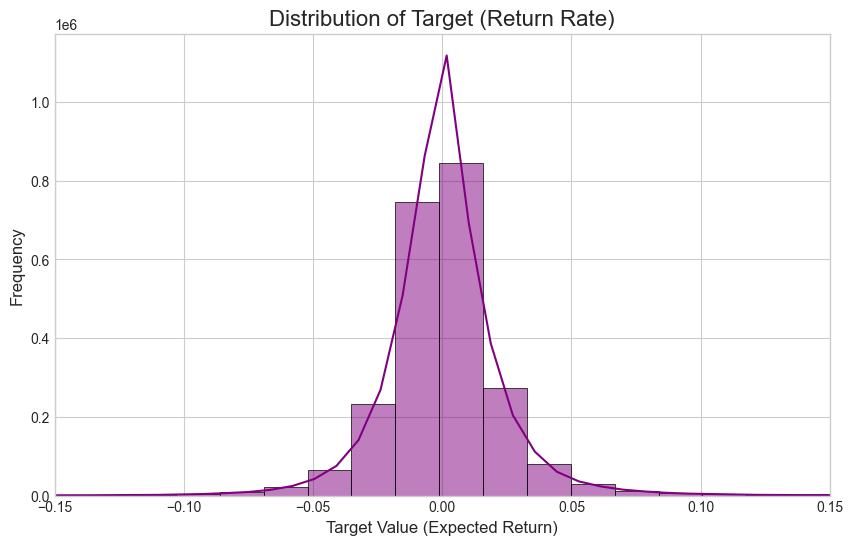

In [1]:
# =====================================================================
# 1단계: 데이터 이해 및 탐색적 데이터 분석 (EDA)
# =====================================================================
# 이 코드는 JPX 주식 예측 대회의 핵심 데이터인 `stock_prices.csv`를 불러와서 
# 데이터의 구조를 파악하고, 기본적인 시각화를 통해 주가 흐름과 우리가 
# 예측해야 할 정답(`Target`)의 분포를 확인합니다.

# 1. 필수 라이브러리 불러오기
from IPython import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 스타일 설정 (깔끔한 출력을 위해)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# 2. 데이터 로드 및 기본 구조 확인
print("데이터 불러오는 중...")
# 현재 노트북이 train_files 폴더 안에 있으므로 파일명만 적어줍니다.
train_prices = pd.read_csv('stock_prices.csv')

# 날짜 열을 문자열에서 datetime 객체로 변환 (시계열 분석을 위해 필수!)
train_prices['Date'] = pd.to_datetime(train_prices['Date'])

print(f"\n데이터 크기 (행, 열): {train_prices.shape}")
print("\n[데이터 처음 5줄 미리보기]")
display(train_prices.head())

# ---------------------------------------------------------------------
# 💡 팁: 위 결과를 보면 종목 코드, 시/고/저/종가, 거래량, 그리고 정답지인 
# 'Target' 열이 존재합니다. 이제 대표적인 종목 하나를 골라서 시계열 주가 
# 흐름 그래프를 그려보겠습니다.
# ---------------------------------------------------------------------

# 3. 특정 종목(예: 7203 - 도요타 자동차)의 시계열 주가 흐름 시각화
target_code = 7203

# 해당 종목 코드의 데이터만 필터링
stock_7203 = train_prices[train_prices['SecuritiesCode'] == target_code].copy()

# 주가 시각화 그리기
plt.figure(figsize=(14, 6))
plt.plot(stock_7203['Date'], stock_7203['Close'], label=f'Stock {target_code} Close Price', color='blue', linewidth=1.5)

plt.title(f'Stock {target_code} - Closing Price Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Closing Price (JPY)', fontsize=12)
plt.legend()
plt.show()

# ---------------------------------------------------------------------
# 🎯 우리가 맞춰야 할 정답, 'Target' 분석
# 'Target'은 오늘 주식을 사서 내일모레 팔았을 때의 수익률을 의미합니다. 
# 이 Target 값이 어떤 분포를 띠고 있는지, 결측치(빈 칸)는 얼마나 있는지 확인합니다.
# ---------------------------------------------------------------------

# 4. Target 변수 결측치 확인 및 분포 시각화
missing_targets = train_prices['Target'].isnull().sum()
total_rows = len(train_prices)
print(f"\n전체 데이터 중 Target 결측치 수: {missing_targets}개 ({missing_targets/total_rows*100:.2f}%)")

# Target 변수 히스토그램 그리기 (결측치는 제외하고 그림)
plt.figure(figsize=(10, 6))
sns.histplot(train_prices['Target'].dropna(), bins=100, kde=True, color='purple')

plt.title('Distribution of Target (Return Rate)', fontsize=16)
plt.xlabel('Target Value (Expected Return)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
# 중심(0)을 기준으로 꼬리(Outlier)를 제외한 주요 분포를 보기 위해 x축 범위 제한
plt.xlim(-0.15, 0.15) 
plt.show()


In [4]:
# =====================================================================
# 2단계 & 3단계: 데이터 전처리 및 특성 공학 (Feature Engineering)
# =====================================================================
# 결측치를 처리하고, 모델 학습에 사용할 유용한 힌트(Features)들을 만듭니다.
# 주의: 주식 지표들은 반드시 '같은 종목 안에서' 그리고 '시간 순서대로' 계산해야 합니다!

import warnings
warnings.filterwarnings('ignore') # 성가신 경고 메시지 숨기기

print("데이터 전처리 및 특성 추출 시작...")


# 1. 데이터 전처리 (Preprocessing)
# 종목별로 과거 날짜부터 순서대로 정렬합니다. (시계열 데이터의 기본!)
train_prices.sort_values(['SecuritiesCode', 'Date'], inplace=True)
train_prices.reset_index(drop=True, inplace=True)


# 2. 특성 공학 함수 정의 (Feature Engineering)
# 나중에 검증 데이터나 Test 데이터에도 똑같은 지표를 만들어야 하므로 함수로 묶어둡니다.
def generate_features(df):
    df = df.copy()

    # 지표는 종목별(SecuritiesCode)로 따로 계산해야 하므로 그룹화 객체 생성
    grouped = df.groupby('SecuritiesCode')

    # 특성 1: 일일 수익률 (Daily Return) - 어제 종가 대비 오늘 종가가 몇 % 올랐나?
    # pct_change() 함수는 이전 행(어제) 대비 변동률을 구해줍니다.
    df['Return'] = grouped['Close'].pct_change()

    # 특성 2: 이동평균 (Moving Average) - 최근 5일, 20일 동안의 평균 주가 흐름 (단기/중기 추세)
    # rolling(window=5).mean() 은 최근 5개의 데이터를 모아서 평균을 냅니다.
    df['MA_5'] = grouped['Close'].transform(
        lambda x: x.rolling(window=5).mean()
    )

    df['MA_20'] = grouped['Close'].transform(
        lambda x: x.rolling(window=20).mean()
    )

    # 특성 3: 이격도 (Disparity) - 현재 주가가 이동평균선에서 얼마나 떨어져 있나? (과열/침체 파악)
    # 1보다 크면 현재 주가가 이동평균보다 높고, 1보다 작으면 이동평균보다 낮다는 뜻입니다.
    df['Disparity_5'] = df['Close'] / df['MA_5']
    df['Disparity_20'] = df['Close'] / df['MA_20']

    # 특성 4: 변동성 (Volatility) - 최근 20일 동안 주가 변동이 얼마나 심했나? (위험도 파악)
    # rolling(window=20).std() 는 최근 수익률의 표준편차를 구하여 변동성을 측정합니다.
    df['Volatility_20'] = (
        df.groupby('SecuritiesCode')['Return']
        .transform(lambda x: x.rolling(window=20).std())
    )


    # 이동평균과 변동성 계산 과정에서 발생한 초기 결측치와
    # Target이 없는 행은 모델 학습에 사용할 수 없으므로 제거합니다.
    # 모델에 실제로 사용하는 Feature와 Target을 기준으로 처리합니다.
    feature_cols = [
        'Return',
        'MA_5',
        'MA_20',
        'Disparity_5',
        'Disparity_20',
        'Volatility_20'
    ]

    df.dropna(
        subset=feature_cols + ['Target'],
        inplace=True
    )

    return df


# 함수를 사용하여 특성이 추가된 새로운 데이터셋 생성
df_features = generate_features(train_prices)

print("\n특성 추출 완료! 추가된 열(Columns)을 확인해보세요:")

# 새로 추가된 지표 열들 위주로 출력 (도요타 7203 종목 예시)
display_cols = [
    'Date',
    'SecuritiesCode',
    'Close',
    'Return',
    'MA_5',
    'Disparity_5',
    'Volatility_20',
    'Target'
]

display(
    df_features[
        df_features['SecuritiesCode'] == 7203
    ][display_cols].head(10)
)

print(f"\n최종 학습 데이터 크기: {df_features.shape}")

데이터 전처리 및 특성 추출 시작...

특성 추출 완료! 추가된 열(Columns)을 확인해보세요:


,Date,SecuritiesCode,Close,Return,MA_5,Disparity_5,Volatility_20,Target
1523941,2017-02-02,7203,6430.0,-0.017721,6593.8,0.975158,0.011634,0.007448
1523942,2017-02-03,7203,6445.0,0.002333,6542.0,0.985173,0.011733,-0.022640
1523943,2017-02-06,7203,6493.0,0.007448,6499.6,0.998985,0.011632,0.006146
1523944,2017-02-07,7203,6346.0,-0.022640,6452.0,0.983571,0.012345,-0.020360
1523945,2017-02-08,7203,6385.0,0.006146,6419.8,0.994579,0.012286,0.030536
1523946,2017-02-09,7203,6255.0,-0.020360,6384.8,0.979670,0.012773,0.006981
1523947,2017-02-10,7203,6446.0,0.030536,6385.0,1.009554,0.014857,-0.005700
1523948,2017-02-13,7203,6491.0,0.006981,6384.6,1.016665,0.014977,0.005733
1523949,2017-02-14,7203,6454.0,-0.005700,6406.2,1.007462,0.014668,-0.005238
1523950,2017-02-15,7203,6491.0,0.005733,6427.4,1.009895,0.014737,-0.008828



최종 학습 데이터 크기: (2217992, 18)


In [5]:
# =====================================================================
# 4단계: 모델 학습 (Model Training)
# =====================================================================
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import datetime

print("모델 학습을 준비합니다...")

# 1. 사용할 특성(Features, X)과 정답(Target, y) 지정하기
# 종목 코드나 날짜 등은 계산식이 아니므로 제외하고, 우리가 만든 지표들만 X로 사용합니다.
features = ['Return', 'MA_5', 'MA_20', 'Disparity_5', 'Disparity_20', 'Volatility_20']
X = df_features[features]
y = df_features['Target']

# 2. 시계열 데이터 분할 (Train / Validation Split)
# **매우 중요**: 무작위로 섞으면 미래 데이터로 과거를 예측하는 오류(Data Leakage)가 발생합니다.
# 특정 날짜를 기준으로 과거는 학습용(Train), 미래는 검증용(Validation)으로 나눕니다.
# JPX train 데이터는 대략 2017년~2021년 말이므로, 2021년 10월 1일을 기준으로 나눠보겠습니다.
split_date = pd.to_datetime('2021-10-01')

# 조건에 맞춰 데이터 나누기
train_data = df_features[df_features['Date'] < split_date]
val_data = df_features[df_features['Date'] >= split_date]

X_train = train_data[features]
y_train = train_data['Target']

X_val = val_data[features]
y_val = val_data['Target']

print(f"학습용(Train) 데이터 크기: {X_train.shape}")
print(f"검증용(Val) 데이터 크기: {X_val.shape}")

# 3. 데이터 스케일링 (Standardization)
# 선형 회귀는 데이터의 크기(Scale)에 민감합니다. 
# 어떤 지표는 10,000단위고 어떤 건 0.01 단위면 모델이 헷갈리므로 평균 0, 분산 1로 맞춰줍니다.
scaler = StandardScaler()

# 학습 데이터로 기준을 맞추고(fit_transform), 검증 데이터에는 그 기준을 똑같이 적용(transform)
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# 4. 선형 회귀 모델 생성 및 훈련
print("\n선형 회귀 모델 훈련 중...")
model = LinearRegression()
model.fit(X_train_scaled, y_train) # 공부 시작!

print("훈련 완료!")

# 5. 검증 데이터로 성능 임시 확인 (MSE)
# 모델이 과연 잘 예측하는지 모의고사를 쳐봅니다.
val_predictions = model.predict(X_val_scaled)

# MSE(평균제곱오차): 예측값과 실제 정답의 차이를 제곱하여 평균 낸 값. 0에 가까울수록 좋습니다.
mse = mean_squared_error(y_val, val_predictions)
print(f"검증 데이터 MSE (Mean Squared Error): {mse:.6f}")

# 선형 회귀 모델이 각 지표(Feature)를 얼마나 중요하게 생각했는지 가중치(Coefficients) 확인
print("\n[모델이 찾아낸 공식의 가중치]")
for feature_name, coef in zip(features, model.coef_):
    print(f"{feature_name:<15}: {coef:.6f}")

# =====================================================================
# [수정된 코드] 모델 성능 상세 평가 (MSE, RMSE, R-squared)
# =====================================================================
import numpy as np
from sklearn.metrics import r2_score

# 1. RMSE (Root Mean Squared Error) 계산
rmse = np.sqrt(mse)

# 2. R^2 (결정계수, R-squared) 계산
# 변수 이름을 현재 셀에 맞춰 val_predictions 로 수정했습니다!
r2 = r2_score(y_val, val_predictions)

print("\n📊 [모델 성능 상세 평가 지표]")
print(f"- MSE  (평균제곱오차)      : {mse:.6f}")
print(f"- RMSE (제곱근 평균제곱오차): {rmse:.6f}")
print(f"- R^2  (결정계수)          : {r2:.6f}")

모델 학습을 준비합니다...
학습용(Train) 데이터 크기: (2131540, 6)
검증용(Val) 데이터 크기: (86452, 6)

선형 회귀 모델 훈련 중...
훈련 완료!
검증 데이터 MSE (Mean Squared Error): 0.000532

[모델이 찾아낸 공식의 가중치]
Return         : 0.000001
MA_5           : 0.000439
MA_20          : -0.000541
Disparity_5    : 0.000167
Disparity_20   : -0.000268
Volatility_20  : 0.000109

📊 [모델 성능 상세 평가 지표]
- MSE  (평균제곱오차)      : 0.000532
- RMSE (제곱근 평균제곱오차): 0.023067
- R^2  (결정계수)          : -0.000500


In [6]:
# =====================================================================
# 5단계: 예측 및 종목 순위(Rank) 매기기 (Ranking)
# =====================================================================
# 모델의 예측값을 바탕으로 매일매일 종목들의 순위를 매깁니다. (0등 ~ 1999등)
import pandas as pd

print("검증 데이터(Validation)에 대한 예측 및 랭킹 산정을 시작합니다...")

# 1. 모델이 예측한 수익률을 검증 데이터셋에 새로운 열로 추가합니다.
val_data['Prediction'] = val_predictions

# 2. 날짜별(Date)로 그룹을 묶어서 랭킹을 매깁니다.
# ascending=False: 예측 수익률이 높은 것이 1등(작은 숫자)이 되도록 내림차순 정렬
# method='first': 만약 예측값이 완전히 똑같은 주식이 있다면 먼저 나온 것을 앞순위로 처리(중복 방지)
# 랭킹은 1등부터 매겨지지만, 캐글 규칙상 0등부터 시작해야 하므로 마지막에 1을 빼줍니다 (- 1)
val_data['Rank'] = val_data.groupby('Date')['Prediction'].rank(ascending=False, method='first') - 1

# 소수점으로 나오는 랭킹을 깔끔한 정수형(int)으로 바꿔줍니다.
val_data['Rank'] = val_data['Rank'].astype(int)

# 3. 랭킹이 제대로 매겨졌는지 확인해봅시다.
# 검증 데이터 중에서 가장 마지막 날짜 하루를 뽑아서 확인해 봅니다.
last_date = val_data['Date'].max()
print(f"\n기준 날짜: {last_date.strftime('%Y-%m-%d')} 기준 랭킹 현황")

# 해당 날짜의 데이터만 추출해서 랭킹 순으로 정렬
daily_ranking = val_data[val_data['Date'] == last_date].sort_values('Rank')

# 모델이 추천하는 "가장 많이 오를 주식" Top 5
print("\n🔥 [추천 매수] 예측 수익률 상위 Top 5 (0등 ~ 4등)")
display_columns = ['SecuritiesCode', 'Close', 'Prediction', 'Target', 'Rank']
display(daily_ranking[display_columns].head(5))

# 모델이 경고하는 "가장 많이 떨어질 주식" Bottom 5
print("\n🧊 [추천 공매도/매도] 예측 수익률 하위 Bottom 5 (가장 꼴찌들)")
display(daily_ranking[display_columns].tail(5))

print("\n🎉 5단계 완료! 모든 주식의 랭킹(Rank)이 0부터 정상적으로 부여되었습니다.")


검증 데이터(Validation)에 대한 예측 및 랭킹 산정을 시작합니다...

기준 날짜: 2021-12-03 기준 랭킹 현황

🔥 [추천 매수] 예측 수익률 상위 Top 5 (0등 ~ 4등)


,SecuritiesCode,Close,Prediction,Target,Rank
198643,2317,454.0,0.002442,0.024444,0
2140792,9369,890.0,0.001865,0.021640,1
743872,4443,2811.0,0.001279,0.005238,2
642229,4056,1797.0,0.001242,0.055843,3
527474,3662,1048.0,0.001231,0.028600,4



🧊 [추천 공매도/매도] 예측 수익률 하위 Bottom 5 (가장 꼴찌들)


,SecuritiesCode,Close,Prediction,Target,Rank
1301395,6532,49550.0,-0.001144,0.057940,1964
1782980,8035,59300.0,-0.001209,0.018815,1965
1183599,6273,74120.0,-0.001608,0.028649,1966
1421544,6861,71010.0,-0.001703,0.017824,1967
2322676,9983,66650.0,-0.002182,0.000737,1968



🎉 5단계 완료! 모든 주식의 랭킹(Rank)이 0부터 정상적으로 부여되었습니다.


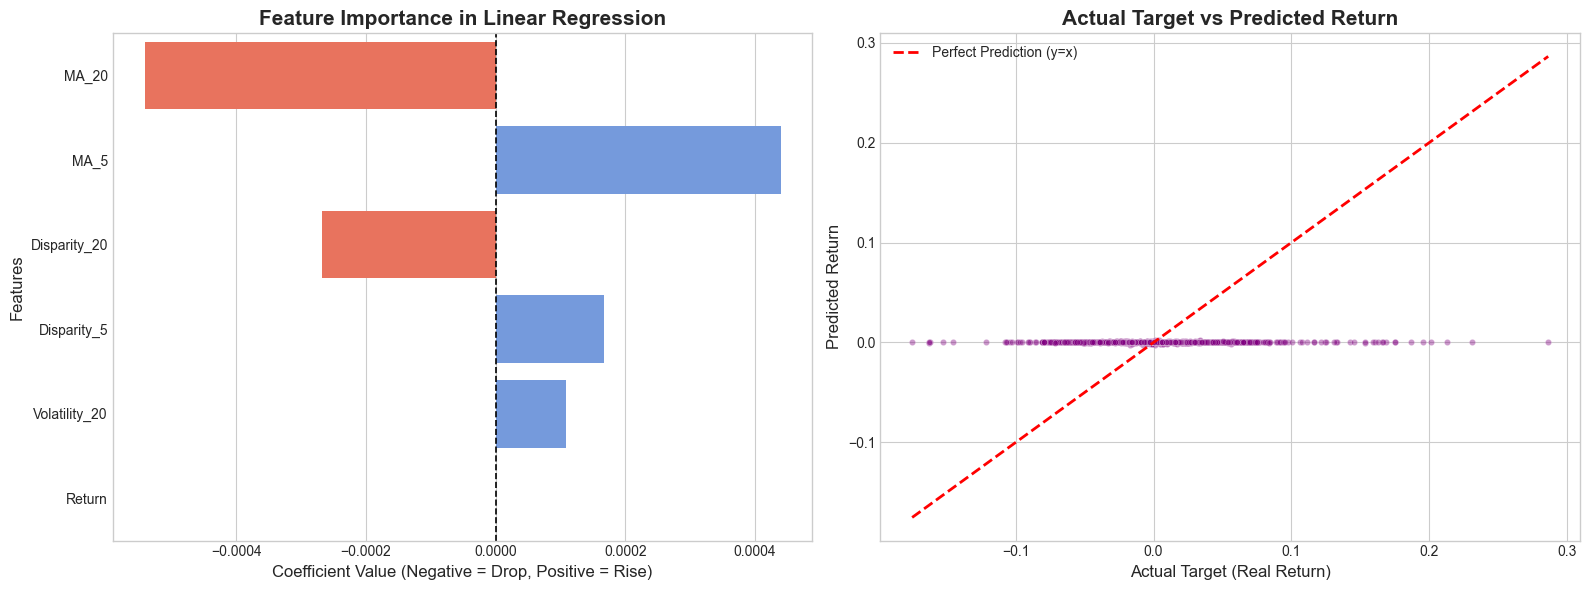

In [7]:
# =====================================================================
# [추가 시각화] 보고서/발표 자료용 모델 평가 시각화 (에러 수정 버전)
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) 

# ---------------------------------------------------------------------
# 시각화 1: Feature Importance (특성 중요도 바 차트)
# ---------------------------------------------------------------------
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_,
    'Abs_Coefficient': np.abs(model.coef_)
}).sort_values(by='Abs_Coefficient', ascending=False)

# [수정된 부분] 리스트 내포(List Comprehension)를 사용하여 안전하게 색상 리스트 생성
custom_colors = ['tomato' if x < 0 else 'cornflowerblue' for x in coef_df['Coefficient']]

# 최신 Seaborn 버전에 맞게 hue 매개변수를 추가하고 legend=False로 설정하여 경고/에러 방지
sns.barplot(x='Coefficient', y='Feature', data=coef_df, ax=axes[0], 
            hue='Feature', palette=custom_colors, legend=False)

axes[0].set_title('Feature Importance in Linear Regression', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Coefficient Value (Negative = Drop, Positive = Rise)', fontsize=12)
axes[0].set_ylabel('Features', fontsize=12)
axes[0].axvline(0, color='black', linewidth=1.2, linestyle='--')

# ---------------------------------------------------------------------
# 시각화 2: 실제 정답(Target) vs 모델 예측값(Prediction) 산점도 (Scatter Plot)
# ---------------------------------------------------------------------
sample_data = val_data.sample(frac=0.1, random_state=42) 

sns.scatterplot(x='Target', y='Prediction', data=sample_data, 
                ax=axes[1], color='purple', alpha=0.4, s=20)

min_val = min(sample_data['Target'].min(), sample_data['Prediction'].min())
max_val = max(sample_data['Target'].max(), sample_data['Prediction'].max())
axes[1].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

axes[1].set_title('Actual Target vs Predicted Return', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Actual Target (Real Return)', fontsize=12)
axes[1].set_ylabel('Predicted Return', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()


In [8]:
# =====================================================================
# 4단계: 모델 학습 (Model Training) - 경사 하강법(SGD) 적용으로 수정됨
# =====================================================================
from sklearn.linear_model import SGDRegressor  # LinearRegression을 SGDRegressor로 변경
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import pandas as pd # datetime 대신 pandas 사용 권장

print("모델 학습을 준비합니다...")

# 1. 사용할 특성(Features, X)과 정답(Target, y) 지정하기
# 종목 코드나 날짜 등은 계산식이 아니므로 제외하고, 우리가 만든 지표들만 X로 사용합니다.
features = ['Return', 'MA_5', 'MA_20', 'Disparity_5', 'Disparity_20', 'Volatility_20']
X = df_features[features]
y = df_features['Target']

# 2. 시계열 데이터 분할 (Train / Validation Split)
# **매우 중요**: 무작위로 섞으면 미래 데이터로 과거를 예측하는 오류(Data Leakage)가 발생합니다.
# 특정 날짜를 기준으로 과거는 학습용(Train), 미래는 검증용(Validation)으로 나눕니다.
split_date = pd.to_datetime('2021-10-01')

# 조건에 맞춰 데이터 나누기
train_data = df_features[df_features['Date'] < split_date].copy()
val_data = df_features[df_features['Date'] >= split_date].copy()

X_train = train_data[features]
y_train = train_data['Target']

X_val = val_data[features]
y_val = val_data['Target']

print(f"학습용(Train) 데이터 크기: {X_train.shape}")
print(f"검증용(Val) 데이터 크기: {X_val.shape}")

# 3. 데이터 스케일링 (Standardization)
# 경사 하강법은 데이터 스케일에 매우 민감하므로 이 단계가 필수적입니다.
scaler = StandardScaler()

# 학습 데이터로 기준을 맞추고(fit_transform), 검증 데이터에는 그 기준을 똑같이 적용(transform)
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# 4. 경사 하강법(SGD) 모델 생성 및 훈련 (수정된 부분!)
print("\n경사 하강법(SGD) 기반 선형 회귀 모델 훈련 중...")
# OLS 방식 대신, 다중공선성에 강하고 확장성이 좋은 SGDRegressor를 사용합니다.
model = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42, penalty='l2')
model.fit(X_train_scaled, y_train) # 공부 시작!

print("훈련 완료!")

# 5. 검증 데이터로 성능 임시 확인 (MSE)
val_predictions = model.predict(X_val_scaled)

# MSE(평균제곱오차): 예측값과 실제 정답의 차이를 제곱하여 평균 낸 값.
mse = mean_squared_error(y_val, val_predictions)
print(f"검증 데이터 MSE (Mean Squared Error): {mse:.6f}")

# 선형 회귀 모델이 각 지표(Feature)를 얼마나 중요하게 생각했는지 가중치(Coefficients) 확인
print("\n[SGD 모델이 찾아낸 공식의 가중치]")
for feature_name, coef in zip(features, model.coef_):
    print(f"{feature_name:<15}: {coef:.6f}")

# =====================================================================
# [수정된 코드] 모델 성능 상세 평가 (MSE, RMSE, R-squared)
# =====================================================================
import numpy as np
from sklearn.metrics import r2_score

# 1. RMSE (Root Mean Squared Error) 계산
rmse = np.sqrt(mse)

# 2. R^2 (결정계수, R-squared) 계산
# 변수 이름을 현재 셀에 맞춰 val_predictions 로 수정했습니다!
r2 = r2_score(y_val, val_predictions)

print("\n📊 [모델 성능 상세 평가 지표]")
print(f"- MSE  (평균제곱오차)      : {mse:.6f}")
print(f"- RMSE (제곱근 평균제곱오차): {rmse:.6f}")
print(f"- R^2  (결정계수)          : {r2:.6f}")



모델 학습을 준비합니다...
학습용(Train) 데이터 크기: (2131540, 6)
검증용(Val) 데이터 크기: (86452, 6)

경사 하강법(SGD) 기반 선형 회귀 모델 훈련 중...
훈련 완료!
검증 데이터 MSE (Mean Squared Error): 0.000533

[SGD 모델이 찾아낸 공식의 가중치]
Return         : -0.000273
MA_5           : 0.001989
MA_20          : -0.002462
Disparity_5    : -0.000123
Disparity_20   : -0.000151
Volatility_20  : 0.000239

📊 [모델 성능 상세 평가 지표]
- MSE  (평균제곱오차)      : 0.000533
- RMSE (제곱근 평균제곱오차): 0.023095
- R^2  (결정계수)          : -0.002995


In [13]:
# =====================================================================
# 5단계: 예측 및 종목 순위(Rank) 매기기 (Ranking)
# =====================================================================
# 모델의 예측값을 바탕으로 매일매일 종목들의 순위를 매깁니다. (0등 ~ 1999등)
import pandas as pd

print("검증 데이터(Validation)에 대한 예측 및 랭킹 산정을 시작합니다...")

# 1. 모델이 예측한 수익률을 검증 데이터셋에 새로운 열로 추가합니다.
val_data['Prediction'] = val_predictions

# 2. 날짜별(Date)로 그룹을 묶어서 랭킹을 매깁니다.
# ascending=False: 예측 수익률이 높은 것이 1등(작은 숫자)이 되도록 내림차순 정렬
# method='first': 만약 예측값이 완전히 똑같은 주식이 있다면 먼저 나온 것을 앞순위로 처리(중복 방지)
# 랭킹은 1등부터 매겨지지만, 캐글 규칙상 0등부터 시작해야 하므로 마지막에 1을 빼줍니다 (- 1)
val_data['Rank'] = val_data.groupby('Date')['Prediction'].rank(ascending=False, method='first') - 1

# 소수점으로 나오는 랭킹을 깔끔한 정수형(int)으로 바꿔줍니다.
val_data['Rank'] = val_data['Rank'].astype(int)

# 3. 랭킹이 제대로 매겨졌는지 확인해봅시다.
# 검증 데이터 중에서 가장 마지막 날짜 하루를 뽑아서 확인해 봅니다.
last_date = val_data['Date'].max()
print(f"\n기준 날짜: {last_date.strftime('%Y-%m-%d')} 기준 랭킹 현황")

# 해당 날짜의 데이터만 추출해서 랭킹 순으로 정렬
daily_ranking = val_data[val_data['Date'] == last_date].sort_values('Rank')

# 모델이 추천하는 "가장 많이 오를 주식" Top 5
print("\n🔥 [추천 매수] 예측 수익률 상위 Top 5 (0등 ~ 4등)")
display_columns = ['SecuritiesCode', 'Close', 'Prediction', 'Target', 'Rank']
display(daily_ranking[display_columns].head(5))

# 모델이 경고하는 "가장 많이 떨어질 주식" Bottom 5
print("\n🧊 [추천 공매도/매도] 예측 수익률 하위 Bottom 5 (가장 꼴찌들)")
display(daily_ranking[display_columns].tail(5))

print("\n🎉 5단계 완료! 모든 주식의 랭킹(Rank)이 0부터 정상적으로 부여되었습니다.")


검증 데이터(Validation)에 대한 예측 및 랭킹 산정을 시작합니다...

기준 날짜: 2021-11-25 기준 랭킹 현황

🔥 [추천 매수] 예측 수익률 상위 Top 5 (0등 ~ 4등)


,SecuritiesCode,Close,Prediction,Target,Rank
2319169,4443,12770.0,0.004599,-0.017516,0
2319107,4187,3880.0,-0.001044,-0.035667,1
2318770,2698,2310.0,-0.001552,-0.000869,2
2319055,3994,8570.0,-0.001972,-0.016627,3
2318658,2168,3575.0,-0.002533,-0.013966,4



🧊 [추천 공매도/매도] 예측 수익률 하위 Bottom 5 (가장 꼴찌들)


,SecuritiesCode,Close,Prediction,Target,Rank
2318807,2830,2597.0,-0.012144,-0.093702,43
2320026,7921,1779.0,-0.012161,-0.029043,44
2320456,9717,1223.0,-0.012355,-0.127517,45
2318917,3377,1045.0,-0.012849,0.046154,46
2318890,3201,917.0,-0.013283,-0.071190,47



🎉 5단계 완료! 모든 주식의 랭킹(Rank)이 0부터 정상적으로 부여되었습니다.


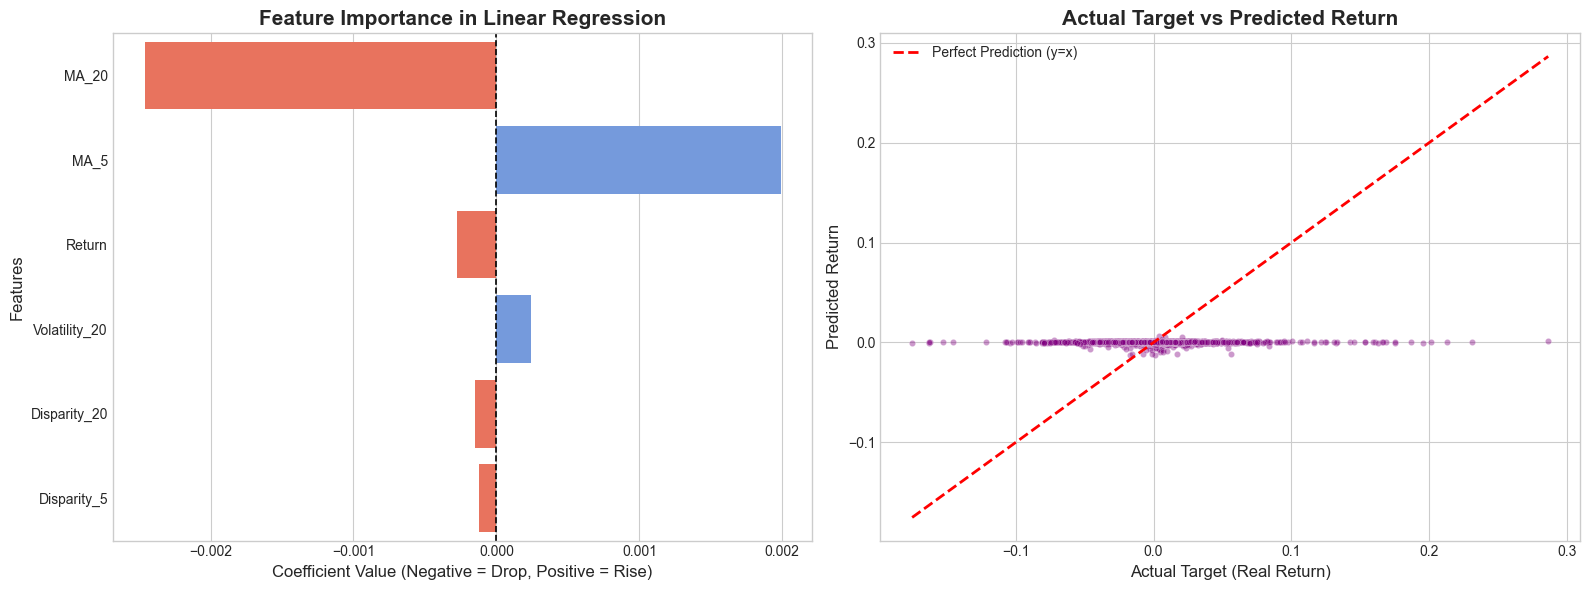

In [12]:
# =====================================================================
# [추가 시각화] 보고서/발표 자료용 모델 평가 시각화 (에러 수정 버전)
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) 

# ---------------------------------------------------------------------
# 시각화 1: Feature Importance (특성 중요도 바 차트)
# ---------------------------------------------------------------------
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_,
    'Abs_Coefficient': np.abs(model.coef_)
}).sort_values(by='Abs_Coefficient', ascending=False)

# [수정된 부분] 리스트 내포(List Comprehension)를 사용하여 안전하게 색상 리스트 생성
custom_colors = ['tomato' if x < 0 else 'cornflowerblue' for x in coef_df['Coefficient']]

# 최신 Seaborn 버전에 맞게 hue 매개변수를 추가하고 legend=False로 설정하여 경고/에러 방지
sns.barplot(x='Coefficient', y='Feature', data=coef_df, ax=axes[0], 
            hue='Feature', palette=custom_colors, legend=False)

axes[0].set_title('Feature Importance in Linear Regression', fontsize=15, fontweight='bold')
axes[0].set_xlabel('Coefficient Value (Negative = Drop, Positive = Rise)', fontsize=12)
axes[0].set_ylabel('Features', fontsize=12)
axes[0].axvline(0, color='black', linewidth=1.2, linestyle='--')

# ---------------------------------------------------------------------
# 시각화 2: 실제 정답(Target) vs 모델 예측값(Prediction) 산점도 (Scatter Plot)
# ---------------------------------------------------------------------

# 모델의 예측 결과를 검증 데이터에 추가
val_data = val_data.copy()
val_data['Prediction'] = val_predictions
sample_data = val_data.sample(frac=0.1, random_state=42) 

sns.scatterplot(x='Target', y='Prediction', data=sample_data, 
                ax=axes[1], color='purple', alpha=0.4, s=20)

min_val = min(sample_data['Target'].min(), sample_data['Prediction'].min())
max_val = max(sample_data['Target'].max(), sample_data['Prediction'].max())
axes[1].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

axes[1].set_title('Actual Target vs Predicted Return', fontsize=15, fontweight='bold')
axes[1].set_xlabel('Actual Target (Real Return)', fontsize=12)
axes[1].set_ylabel('Predicted Return', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()


기업 정보(stock_list.csv)를 불러와 랭킹과 결합하는 중...

📊 기준 날짜 [2021-12-03] 최종 예측 랭킹 결과

🔥 [매수 추천 Top 15 종목 리스트]


,Rank,SecuritiesCode,Name,33SectorName,Prediction
0,0,2317,Systena Corporation,Information & Communication,0.002442
1,1,9369,K.R.S.Corporation,Warehousing and Harbor Transportation Service,0.001865
2,2,4443,"Sansan,Inc.",Information & Communication,0.001279
3,3,4056,Neural Pocket Inc.,Information & Communication,0.001242
4,4,3662,Ateam Inc.,Information & Communication,0.001231
5,5,7816,"Snow Peak,Inc.",Other Products,0.001226
6,6,7048,VELTRA Corporation,Services,0.001184
7,7,3926,Open Door Inc.,Information & Communication,0.001133
8,8,9274,"KOKUSAI PULP & PAPER CO.,LTD.",Wholesale Trade,0.001099
9,9,2170,Link and Motivation Inc.,Services,0.001046



🧊 [매도(공매도) 추천 Bottom 15 종목 리스트]


,Rank,SecuritiesCode,Name,33SectorName,Prediction
1954,1954,9843,"Nitori Holdings Co.,Ltd.",Retail Trade,-0.000013
1955,1955,4684,"OBIC Co.,Ltd.",Information & Communication,-0.000072
1956,1956,6367,"DAIKIN INDUSTRIES,LTD.",Machinery,-0.000099
1957,1957,6954,FANUC CORPORATION,Electric Appliances,-0.000111
1958,1958,4051,"GMO Financial Gate,Inc.",Information & Communication,-0.000289
1959,1959,3697,SHIFT Inc.,Information & Communication,-0.000298
1960,1960,6920,Lasertec Corporation,Electric Appliances,-0.000317
1961,1961,7309,SHIMANO INC.,Transportation Equipment,-0.000335
1962,1962,6146,DISCO CORPORATION,Machinery,-0.000435
1963,1963,7974,"Nintendo Co.,Ltd.",Other Products,-0.000937



---------------------------------------------------------
📊 위 리스트를 바탕으로 한 [업종별 빈도 요약표]
---------------------------------------------------------

[Top 15 업종 요약]


,Sector,Count
0,Information & Communication,5
1,Services,4
2,Wholesale Trade,2
3,Warehousing and Harbor Transportation Service,1
4,Other Products,1
5,Electric Appliances,1
6,Pharmaceutical,1



[Bottom 15 업종 요약]


,Sector,Count
0,Electric Appliances,4
1,Information & Communication,3
2,Machinery,3
3,Retail Trade,2
4,Transportation Equipment,1
5,Other Products,1
6,Services,1


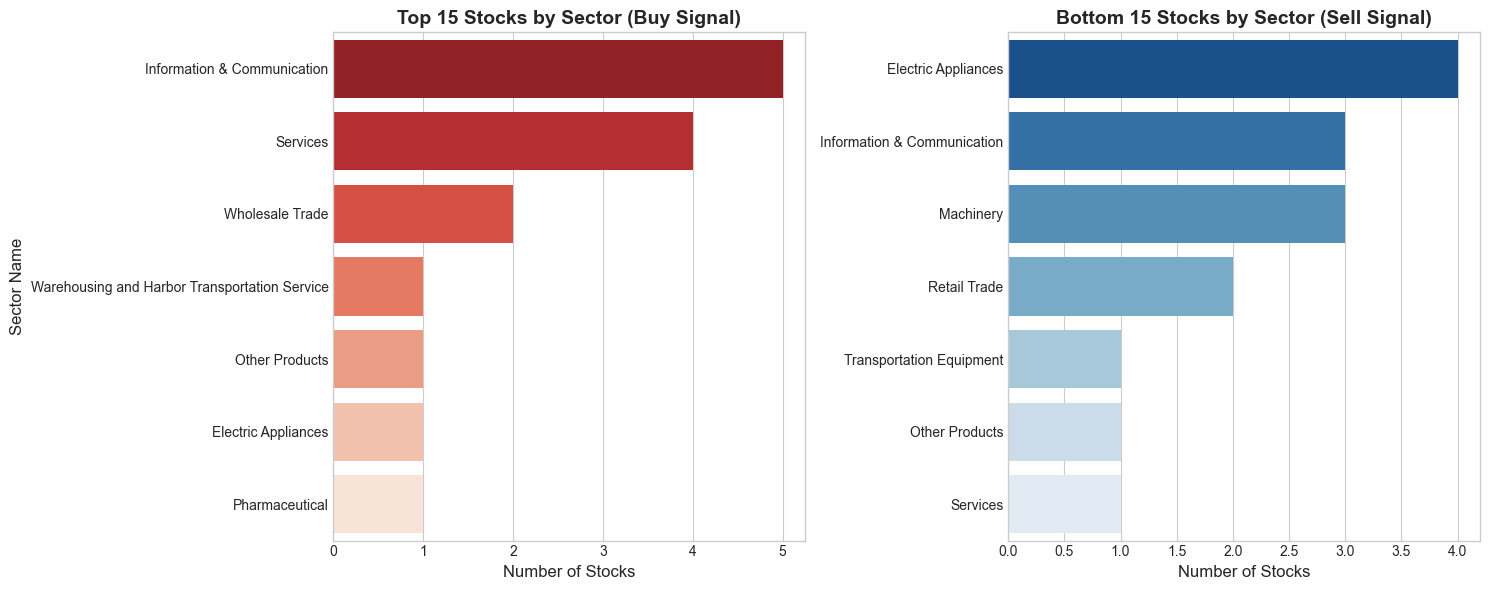

In [13]:
# =====================================================================
# [통합본] 랭킹 리스트(Top/Bottom 15) 출력 및 업종 분포 시각화 분석
# =====================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("기업 정보(stock_list.csv)를 불러와 랭킹과 결합하는 중...")
print("\n📊 기준 날짜 [2021-12-03] 최종 예측 랭킹 결과")

# 1. 주식 리스트 불러와서 랭킹 데이터(daily_ranking)와 합치기 (Merge)
try:
    stock_list = pd.read_csv('stock_list.csv')
except FileNotFoundError:
    stock_list = pd.read_csv('../stock_list.csv') 

info_df = stock_list[['SecuritiesCode', 'Name', '33SectorName']]
enriched_ranking = pd.merge(daily_ranking, info_df, on='SecuritiesCode', how='left')

# 2. 상위 15개, 하위 15개 종목 추출
top_15 = enriched_ranking.head(15)
bottom_15 = enriched_ranking.tail(15)

# ---------------------------------------------------------------------
# 3. [추가된 부분] 랭킹에 등록된 실제 15개 종목 리스트 텍스트 출력
# ---------------------------------------------------------------------
# 보고 싶은 열(Column)만 깔끔하게 지정
display_cols = ['Rank', 'SecuritiesCode', 'Name', '33SectorName', 'Prediction']

print("\n🔥 [매수 추천 Top 15 종목 리스트]")
display(top_15[display_cols])

print("\n🧊 [매도(공매도) 추천 Bottom 15 종목 리스트]")
display(bottom_15[display_cols])


# ---------------------------------------------------------------------
# 4. 업종별 빈도수(개수) 계산 및 요약 출력
# ---------------------------------------------------------------------
top_sectors = top_15['33SectorName'].value_counts().reset_index()
top_sectors.columns = ['Sector', 'Count']

bottom_sectors = bottom_15['33SectorName'].value_counts().reset_index()
bottom_sectors.columns = ['Sector', 'Count']

print("\n---------------------------------------------------------")
print("📊 위 리스트를 바탕으로 한 [업종별 빈도 요약표]")
print("---------------------------------------------------------")
print("\n[Top 15 업종 요약]")
display(top_sectors)

print("\n[Bottom 15 업종 요약]")
display(bottom_sectors)


# ---------------------------------------------------------------------
# 5. 시각화 (막대 그래프)
# ---------------------------------------------------------------------
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 왼쪽: 매수 추천 업종
sns.barplot(x='Count', y='Sector', data=top_sectors, ax=axes[0], palette='Reds_r')
axes[0].set_title('Top 15 Stocks by Sector (Buy Signal)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Stocks', fontsize=12)
axes[0].set_ylabel('Sector Name', fontsize=12)

# 오른쪽: 매도 추천 업종
sns.barplot(x='Count', y='Sector', data=bottom_sectors, ax=axes[1], palette='Blues_r')
axes[1].set_title('Bottom 15 Stocks by Sector (Sell Signal)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Stocks', fontsize=12)
axes[1].set_ylabel('') # y축 이름 생략 (깔끔하게)

plt.tight_layout()
plt.show()
